In [7]:
import pandas as pd
# Import thư viện vẽ biểu đồ
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_palette('husl')
# Import thư viện machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import SMOTE để cân bằng dữ liệu
from imblearn.over_sampling import SMOTE
# Đọc dữ liệu ĐÃ LÀM SẠCH
df = pd.read_csv("traffic_clean.csv")

### Chọn các Features quan trọng

Chọn 10 features dễ hiểu và có ý nghĩa thực tế:

In [8]:
# Chọn các cột features quan trọng
selected_features = [
    'weather_condition',           # Điều kiện thời tiết
    'lighting_condition',          # Điều kiện ánh sáng
    'roadway_surface_cond',        # Tình trạng mặt đường
    'first_crash_type',            # Loại va chạm
    'crash_hour',                  # Giờ xảy ra tai nạn
    'crash_day_of_week',           # Ngày trong tuần
    'crash_month',                 # Tháng
    'num_units',                   # Số phương tiện
    'prim_contributory_cause',     # Nguyên nhân chính
    'traffic_control_device'       # Thiết bị điều khiển giao thông
]

# Tạo dataframe mới với features đã chọn và target
df_model = df[selected_features + ['is_severe']].copy()

print(f"\n Đã chọn {len(selected_features)} features cho mô hình")
print(f"Kích thước dữ liệu mới: {df_model.shape}")


 Đã chọn 10 features cho mô hình
Kích thước dữ liệu mới: (201268, 11)


---
## MÃ HÓA DỮ LIỆU (ENCODING)

### 1. Mã hóa các biến Categorical bằng Label Encoding

Label Encoding chuyển đổi categorical variables thành số nguyên (0, 1, 2, ...).

In [9]:
# Xác định các cột categorical
categorical_cols = [
    'weather_condition',
    'lighting_condition',
    'roadway_surface_cond',
    'first_crash_type',
    'prim_contributory_cause',
    'traffic_control_device'
]

# Tạo bản sao để mã hóa
df_encoded = df_model.copy()

# Áp dụng Label Encoding cho từng cột
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"Đã mã hóa: {col} ({len(le.classes_)} categories)")

print(f"\nHoàn thành mã hóa {len(categorical_cols)} cột categorical!")

Đã mã hóa: weather_condition (12 categories)
Đã mã hóa: lighting_condition (5 categories)
Đã mã hóa: roadway_surface_cond (7 categories)
Đã mã hóa: first_crash_type (18 categories)
Đã mã hóa: prim_contributory_cause (40 categories)
Đã mã hóa: traffic_control_device (18 categories)

Hoàn thành mã hóa 6 cột categorical!


In [10]:
# Xem dữ liệu sau khi mã hóa
print("\nDỮ LIỆU SAU KHI MÃ HÓA:")
df_encoded.head(10)


DỮ LIỆU SAU KHI MÃ HÓA:


,weather_condition,lighting_condition,roadway_surface_cond,first_crash_type,crash_hour,crash_day_of_week,crash_month,num_units,prim_contributory_cause,traffic_control_device,is_severe
0,2,3,5,17,13,7,7,2,36,16,0
1,2,1,0,17,0,1,8,2,24,16,0
2,2,3,0,10,10,5,12,3,19,16,0
3,2,3,0,0,19,4,8,2,36,16,1
4,2,3,5,10,14,7,8,2,12,16,0
5,7,1,6,2,0,4,9,1,36,4,1
6,2,3,0,11,11,3,12,2,21,16,0
7,2,3,0,0,14,4,9,2,18,4,1
8,2,3,0,10,18,2,6,2,19,16,0
9,2,3,0,0,17,5,9,2,18,15,0


---
## CHIA DỮ LIỆU VÀ CÂN BẰNG (TRAIN/TEST SPLIT & SMOTE)

### 1. Chia dữ liệu Train/Test (80/20)

In [11]:
# Tách features (X) và target (y)
X = df_encoded.drop('is_severe', axis=1)
y = df_encoded['is_severe']

print(f"Kích thước X (Features): {X.shape}")
print(f"Kích thước y (Target): {y.shape}")
print(f"\nDanh sách Features:")

for i, col in enumerate(X.columns, 1):    print(f"  {i}. {col}")

Kích thước X (Features): (201268, 10)
Kích thước y (Target): (201268,)

Danh sách Features:
  1. weather_condition
  2. lighting_condition
  3. roadway_surface_cond
  4. first_crash_type
  5. crash_hour
  6. crash_day_of_week
  7. crash_month
  8. num_units
  9. prim_contributory_cause
  10. traffic_control_device


In [12]:
# Chia train/test với stratify để giữ tỷ lệ class
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nĐã chia dữ liệu:")
print(f"  Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nPhân phối class trong Training set:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)


Đã chia dữ liệu:
  Training set: 161,014 samples (80.0%)
  Test set: 40,254 samples (20.0%)

Phân phối class trong Training set:
is_severe
0    118435
1     42579
Name: count, dtype: int64
is_severe
0    73.555716
1    26.444284
Name: proportion, dtype: float64


### 2. Chuẩn hóa dữ liệu (Standardization)

In [13]:
# Chuẩn hóa features bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Đã chuẩn hóa dữ liệu (mean=0, std=1)")
print(f"\nThống kê sau chuẩn hóa (Training set):")
print(f"  Mean: {X_train_scaled.mean():.6f}")
print(f"  Std: {X_train_scaled.std():.6f}")

Đã chuẩn hóa dữ liệu (mean=0, std=1)

Thống kê sau chuẩn hóa (Training set):
  Mean: -0.000000
  Std: 1.000000


### 3. Áp dụng SMOTE để cân bằng dữ liệu

In [14]:
# Áp dụng SMOTE chỉ trên training set
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("Đã hoàn thành SMOTE!")
print(f"\nDữ liệu TRƯỚC SMOTE:")
print(f"  Tổng: {len(y_train):,} samples")
print(y_train.value_counts())

print(f"\nDữ liệu SAU SMOTE:")
print(f"  Tổng: {len(y_train_balanced):,} samples")
print(pd.Series(y_train_balanced).value_counts())

print("\nDữ liệu đã được cân bằng!")

Đã hoàn thành SMOTE!

Dữ liệu TRƯỚC SMOTE:
  Tổng: 161,014 samples
is_severe
0    118435
1     42579
Name: count, dtype: int64

Dữ liệu SAU SMOTE:
  Tổng: 236,870 samples
is_severe
1    118435
0    118435
Name: count, dtype: int64

Dữ liệu đã được cân bằng!


---
## XÂY DỰNG VÀ HUẤN LUYỆN MÔ HÌNH

### 1. Model 1: Logistic Regression

In [15]:
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

# Khởi tạo và huấn luyện
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_balanced, y_train_balanced)

# Dự đoán
y_pred_lr = lr_model.predict(X_test_scaled)

# Đánh giá
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"\nĐã huấn luyện Logistic Regression")
print(f"Accuracy: {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")

MODEL 1: LOGISTIC REGRESSION

Đã huấn luyện Logistic Regression
Accuracy: 0.6206 (62.06%)


### 2. Model 2: Naive Bayes

In [16]:
print("MODEL 2: NAIVE BAYES")
print("="*50)

# Khởi tạo và huấn luyện
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)

# Dự đoán
y_pred_nb = nb_model.predict(X_test_scaled)

# Đánh giá
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"\nĐã huấn luyện Naive Bayes")
print(f"Accuracy: {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")

MODEL 2: NAIVE BAYES

Đã huấn luyện Naive Bayes
Accuracy: 0.6751 (67.51%)


### 3. Model 3: Random Forest

In [17]:
print("MODEL 3: RANDOM FOREST")
print("="*50)

# Khởi tạo và huấn luyện
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_balanced, y_train_balanced)

# Dự đoán
y_pred_rf = rf_model.predict(X_test_scaled)

# Đánh giá
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nĐã huấn luyện Random Forest")
print(f"Accuracy: {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")

MODEL 3: RANDOM FOREST

Đã huấn luyện Random Forest
Accuracy: 0.7407 (74.07%)


### 4. Model 4: XGBoost (Gradient Boosting)

XGBoost là thuật toán Gradient Boosting mạnh mẽ, thường cho kết quả tốt nhất với dữ liệu bảng.

In [18]:
from xgboost import XGBClassifier
import time

print("MODEL 4: XGBOOST (GRADIENT BOOSTING)")
print("="*50)

start_time = time.time()

# Khởi tạo XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

# Dự đoán
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Đánh giá
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
elapsed_time = time.time() - start_time

print(f"Accuracy: {accuracy_xgb:.4f} ({accuracy_xgb*100:.2f}%)")


MODEL 4: XGBOOST (GRADIENT BOOSTING)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.7801 (78.01%)


---
## ĐÁNH GIÁ VÀ SO SÁNH MÔ HÌNH

### 1. Bảng So sánh Accuracy

In [19]:
# Tạo bảng so sánh 4 models
results_df = pd.DataFrame({
    'Mô hình': ['Logistic Regression', 'Naive Bayes', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_rf, accuracy_xgb],
    'Accuracy (%)': [accuracy_lr*100, accuracy_nb*100, accuracy_rf*100, accuracy_xgb*100]
})
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nBẢNG SO SÁNH HIỆU SUẤT 4 MÔ HÌNH")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

best_model = results_df.iloc[0]['Mô hình']
best_accuracy = results_df.iloc[0]['Accuracy (%)']
print(f"\nMÔ HÌNH TỐT NHẤT: {best_model} ({best_accuracy:.2f}%)")


BẢNG SO SÁNH HIỆU SUẤT 4 MÔ HÌNH
            Mô hình  Accuracy  Accuracy (%)
            XGBoost  0.780072     78.007155
      Random Forest  0.740672     74.067173
        Naive Bayes  0.675113     67.511303
Logistic Regression  0.620584     62.058429

MÔ HÌNH TỐT NHẤT: XGBoost (78.01%)


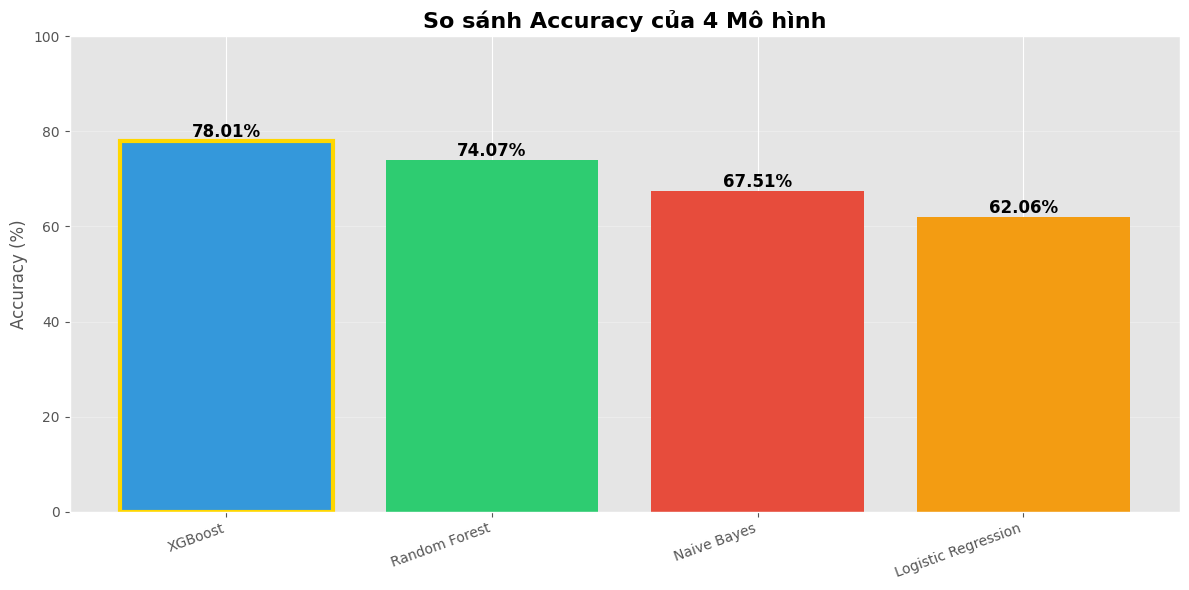

In [20]:
# Vẽ biểu đồ so sánh 4 models
plt.figure(figsize=(12, 6))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
bars = plt.bar(results_df['Mô hình'], results_df['Accuracy (%)'], color=colors)

plt.title('So sánh Accuracy của 4 Mô hình', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=20, ha='right')

# Thêm giá trị lên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Đánh dấu model tốt nhất

best_idx = results_df['Accuracy (%)'].idxmax()
bars[best_idx].set_edgecolor('gold')
bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 2. K-Fold Cross Validation

In [21]:
from sklearn.model_selection import cross_val_score

# Cross validation cho 4 models
models_cv = [
    ('Logistic Regression', lr_model),
    ('Naive Bayes', nb_model),
    ('Random Forest', rf_model),
    ('XGBoost', xgb_model)
]

cv_results = []
for name, model in models_cv:
    # Tắt n_jobs cho Random Forest để tránh memory error
    n_jobs_cv = 1 if name == 'Random Forest' else -1

    print(f"{name}")
    scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                            cv=10, scoring='accuracy', n_jobs=n_jobs_cv)
    cv_results.append({
        'Mô hình': name,
        'Trung bình': scores.mean(),
        'Độ lệch chuẩn': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })
    print(f"  Accuracy trung bình: {scores.mean():.4f} ({scores.mean()*100:.2f}%)")
    print(f"  Độ lệch chuẩn: ±{scores.std():.4f}")
    print(f"  Khoảng [Min-Max]: [{scores.min():.4f} - {scores.max():.4f}]")

cv_df = pd.DataFrame(cv_results)
print("\n" + "="*60)
print("BẢNG TỔNG HỢP K-FOLD CROSS VALIDATION (K=10)")
print(cv_df.to_string(index=False))

Logistic Regression
  Accuracy trung bình: 0.5931 (59.31%)
  Độ lệch chuẩn: ±0.0028
  Khoảng [Min-Max]: [0.5892 - 0.5969]
Naive Bayes
  Accuracy trung bình: 0.5744 (57.44%)
  Độ lệch chuẩn: ±0.0023
  Khoảng [Min-Max]: [0.5711 - 0.5776]
Random Forest
  Accuracy trung bình: 0.8230 (82.30%)
  Độ lệch chuẩn: ±0.1096
  Khoảng [Min-Max]: [0.6652 - 0.9121]
XGBoost
  Accuracy trung bình: 0.8250 (82.50%)
  Độ lệch chuẩn: ±0.1312
  Khoảng [Min-Max]: [0.6376 - 0.9319]

BẢNG TỔNG HỢP K-FOLD CROSS VALIDATION (K=10)
            Mô hình  Trung bình  Độ lệch chuẩn      Min      Max
Logistic Regression    0.593119       0.002763 0.589184 0.596867
        Naive Bayes    0.574391       0.002256 0.571073 0.577616
      Random Forest    0.823038       0.109631 0.665217 0.912104
            XGBoost    0.825031       0.131232 0.637607 0.931861


### 3. ROC Curve & AUC

ROC CURVE & AUC SCORE


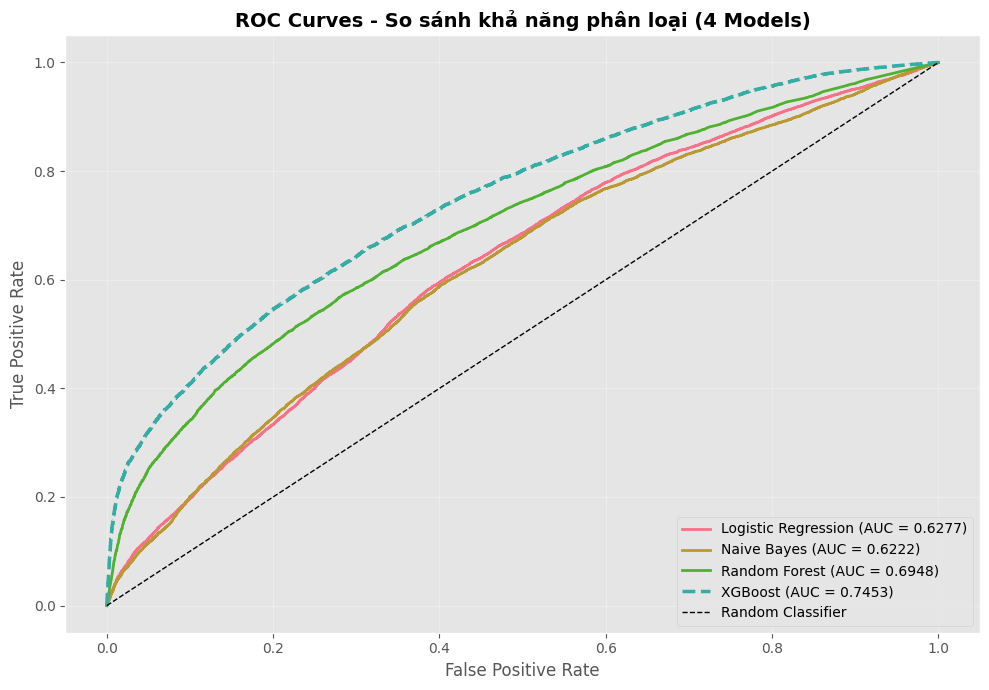


AUC SCORES:
  Logistic Regression: 0.6277
  Naive Bayes: 0.6222
  XGBoost: 0.7453
  Random Forest: 0.6948


In [22]:
from sklearn.metrics import roc_curve, auc

print("ROC CURVE & AUC SCORE")
print("="*60)

# Lấy probability predictions cho ROC curve (4 models)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Tính ROC curve và AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

auc_lr = auc(fpr_lr, tpr_lr)
auc_nb = auc(fpr_nb, tpr_nb)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Vẽ ROC curves (4 models)
plt.figure(figsize=(10, 7))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {auc_nb:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2.5, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - So sánh khả năng phân loại (4 Models)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# In kết quả AUC
print("\nAUC SCORES:")

print(f"  Logistic Regression: {auc_lr:.4f}")
print(f"  Naive Bayes: {auc_nb:.4f}")
print(f"  XGBoost: {auc_xgb:.4f}")
print(f"  Random Forest: {auc_rf:.4f}")

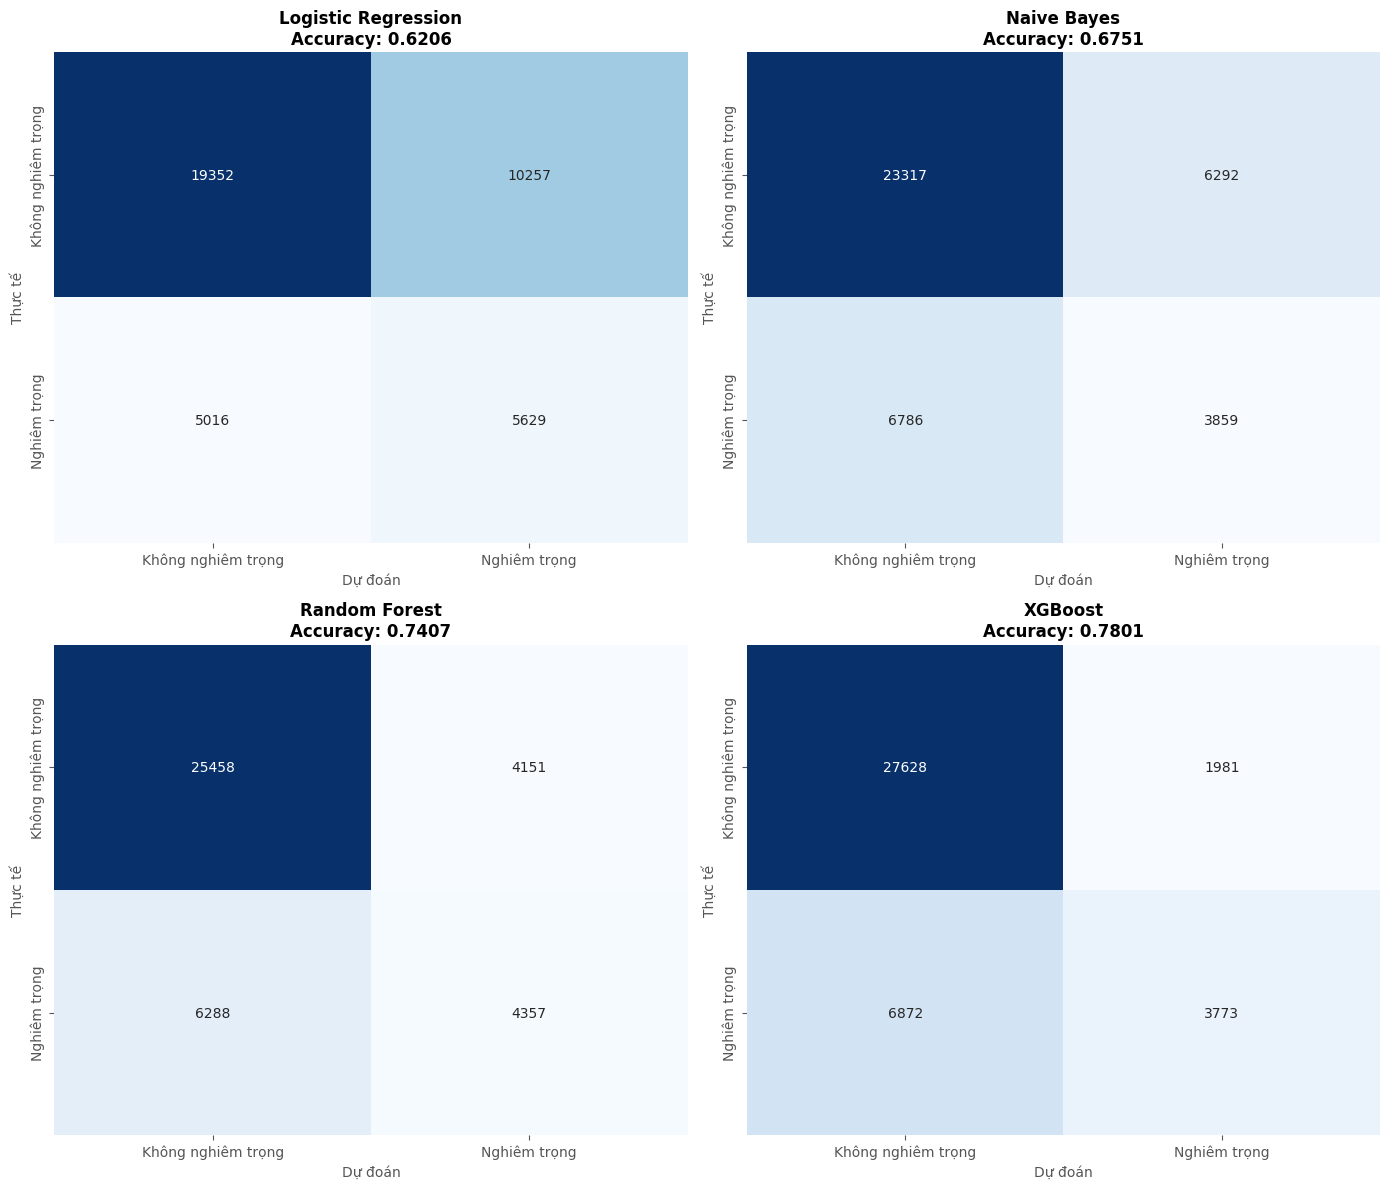


Confusion Matrix giải thích:
  - Góc trên trái: Dự đoán ĐÚNG 'Không nghiêm trọng'
  - Góc dưới phải: Dự đoán ĐÚNG 'Nghiêm trọng'
  - Góc trên phải: Dự đoán SAI (False Positive)
  - Góc dưới trái: Dự đoán SAI (False Negative)


In [23]:
# Tạo Confusion Matrix cho 4 models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

models = [
    ('Logistic Regression', y_pred_lr),
    ('Naive Bayes', y_pred_nb),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for idx, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Không nghiêm trọng', 'Nghiêm trọng'],
                yticklabels=['Không nghiêm trọng', 'Nghiêm trọng'],
                cbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, y_pred):.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Thực tế', fontsize=10)
    axes[idx].set_xlabel('Dự đoán', fontsize=10)

plt.tight_layout()
plt.show()

print("\nConfusion Matrix giải thích:")
print("  - Góc trên trái: Dự đoán ĐÚNG 'Không nghiêm trọng'")
print("  - Góc dưới phải: Dự đoán ĐÚNG 'Nghiêm trọng'")
print("  - Góc trên phải: Dự đoán SAI (False Positive)")
print("  - Góc dưới trái: Dự đoán SAI (False Negative)")

### 3. Classification Report chi tiết

In [24]:
print("CLASSIFICATION REPORT CHI TIẾT - 4 MÔ HÌNH")
print("="*70)

models_report = [
    ('LOGISTIC REGRESSION', y_pred_lr),
    ('NAIVE BAYES', y_pred_nb),
    ('RANDOM FOREST', y_pred_rf),
    ('XGBOOST', y_pred_xgb)
]

for name, y_pred in models_report:
    print(f"\n{name}")
    print("-" * 70)
    print(classification_report(y_test, y_pred,
                                target_names=['Không nghiêm trọng', 'Nghiêm trọng']))

print("="*70)
print("Giải thích các chỉ số:")
print("  - Precision: Trong số dự đoán NGHIÊM TRỌNG, bao nhiêu % là đúng?")

print("  - Recall: Trong số thực tế NGHIÊM TRỌNG, model tìm được bao nhiêu %?")
print("  - Support: Số lượng mẫu thực tế của mỗi class")
print("  - F1-Score: Trung bình điều hòa của Precision và Recall")

CLASSIFICATION REPORT CHI TIẾT - 4 MÔ HÌNH

LOGISTIC REGRESSION
----------------------------------------------------------------------
                    precision    recall  f1-score   support

Không nghiêm trọng       0.79      0.65      0.72     29609
      Nghiêm trọng       0.35      0.53      0.42     10645

          accuracy                           0.62     40254
         macro avg       0.57      0.59      0.57     40254
      weighted avg       0.68      0.62      0.64     40254


NAIVE BAYES
----------------------------------------------------------------------
                    precision    recall  f1-score   support

Không nghiêm trọng       0.77      0.79      0.78     29609
      Nghiêm trọng       0.38      0.36      0.37     10645

          accuracy                           0.68     40254
         macro avg       0.58      0.58      0.58     40254
      weighted avg       0.67      0.68      0.67     40254


RANDOM FOREST
----------------------------------------

### 4. Feature Importance từ XGBoost

In [25]:
# Lấy feature importance từ XGBoost (model tốt nhất)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 10 FEATURES QUAN TRỌNG NHẤT (XGBoost)")
print(feature_importance.head(10).to_string(index=False))



TOP 10 FEATURES QUAN TRỌNG NHẤT (XGBoost)
                Feature  Importance
       first_crash_type    0.350731
 traffic_control_device    0.178537
            crash_month    0.092330
prim_contributory_cause    0.088823
              num_units    0.082236
             crash_hour    0.078575
      weather_condition    0.035785
      crash_day_of_week    0.035095
   roadway_surface_cond    0.034360
     lighting_condition    0.023527


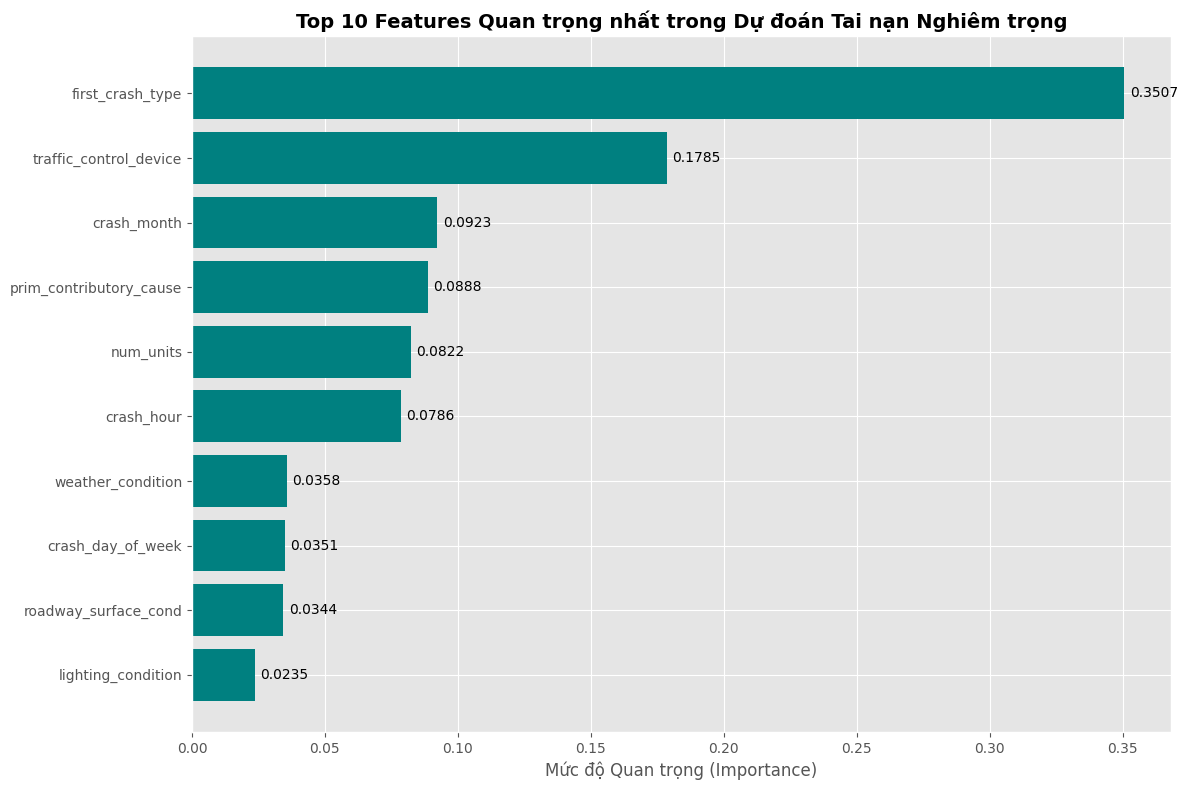


Feature ảnh hưởng NHIỀU NHẤT: first_crash_type
   Mức độ quan trọng: 0.3507 (35.07%)

Top 3 features quan trọng nhất:
   4. first_crash_type: 0.3507
   10. traffic_control_device: 0.1785
   7. crash_month: 0.0923


In [26]:
# Vẽ biểu đồ Feature Importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
bars = plt.barh(range(len(top_features)), top_features['Importance'], color='teal')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Mức độ Quan trọng (Importance)', fontsize=12)
plt.title('Top 10 Features Quan trọng nhất trong Dự đoán Tai nạn Nghiêm trọng',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Thêm giá trị
for i, (bar, value) in enumerate(zip(bars, top_features['Importance'])):
    plt.text(value + 0.002, i, f'{value:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Phân tích feature quan trọng nhất
most_important = feature_importance.iloc[0]['Feature']
most_important_score = feature_importance.iloc[0]['Importance']
print(f"\nFeature ảnh hưởng NHIỀU NHẤT: {most_important}")
print(f"   Mức độ quan trọng: {most_important_score:.4f} ({most_important_score*100:.2f}%)")
print(f"\nTop 3 features quan trọng nhất:")
for i, row in feature_importance.head(3).iterrows():
    print(f"   {i+1}. {row['Feature']}: {row['Importance']:.4f}")